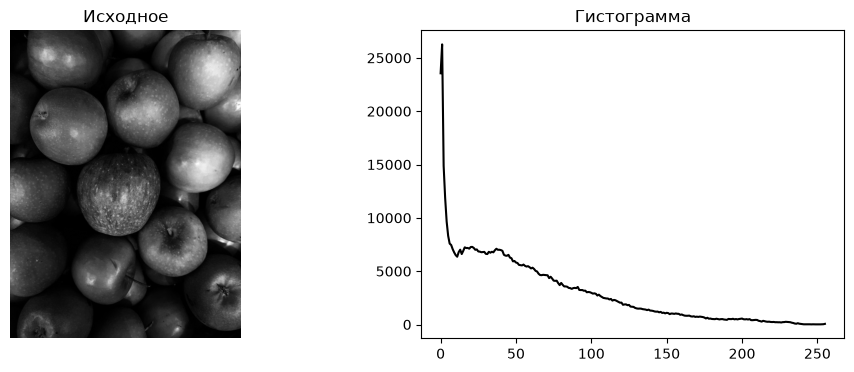

In [26]:
#1
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

img = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)
hist = cv2.calcHist([img], [0], None, [256], (0, 256))

#гистограмма
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(img, cmap='gray'); ax[0].set_title('Исходное'); ax[0].axis('off')
ax[1].plot(hist, color='black'); ax[1].set_title('Гистограмма')
plt.show()

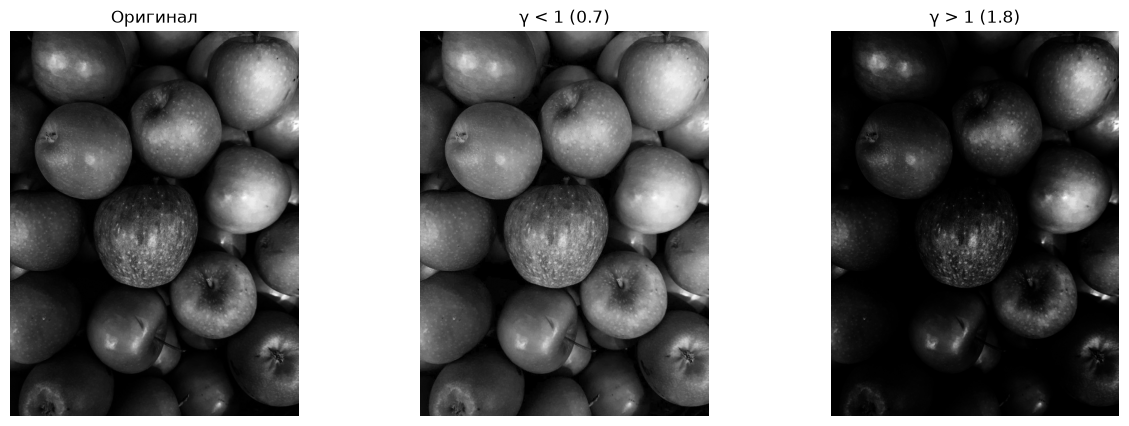

In [25]:
#реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
def gamma_correction(image, gamma):
    return np.uint8(np.power(image / 255.0, gamma) * 255)

img_low  = gamma_correction(img, 0.7)   # γ < 1
img_high = gamma_correction(img, 1.8)   # γ > 1

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img, cmap='gray');      ax[0].set_title('Оригинал')
ax[1].imshow(img_low, cmap='gray');  ax[1].set_title('γ < 1 (0.7)')
ax[2].imshow(img_high, cmap='gray'); ax[2].set_title('γ > 1 (1.8)')
for a in ax: a.axis('off')
plt.show()

In [20]:
#Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
for name, im in [('γ < 1', img_low), ('γ > 1', img_high)]:
    s, _ = structural_similarity(img, im, full=True)
    m = mean_squared_error(img, im)
    print(f"{name}: SSIM = {s:.3f}, MSE = {m:.3f}")

γ < 1: SSIM = 0.836, MSE = 684.147
γ > 1: SSIM = 0.520, MSE = 1313.879


Стат. коррекция: SSIM = 0.595, MSE = 4327.015


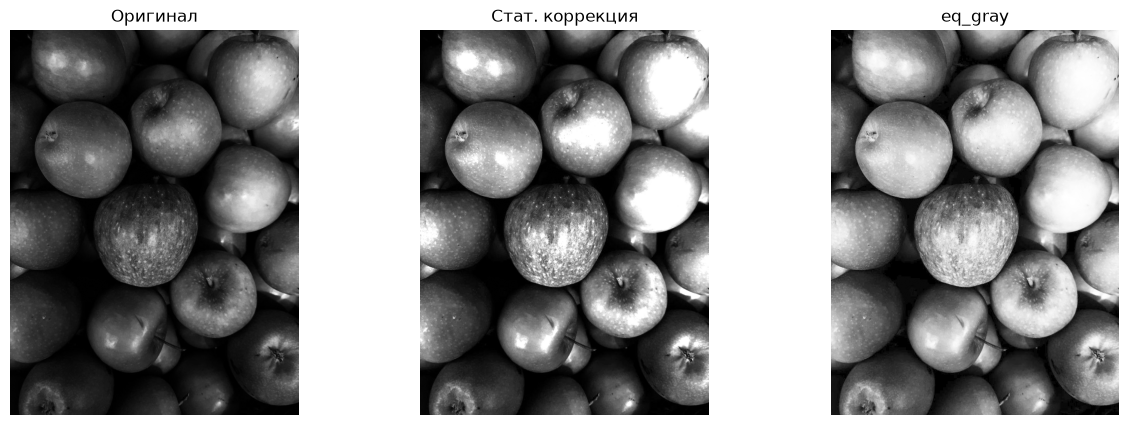

In [21]:
#реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
def stat_correction(image, reference):
    mu_s, sd_s = image.mean(), image.std()
    mu_r, sd_r = reference.mean(), reference.std()
    return np.clip((image - mu_s) * (sd_r / sd_s) + mu_r, 0, 255).astype(np.uint8)

eq_gray = cv2.equalizeHist(img)
img_stat = stat_correction(img, eq_gray)

s, _ = structural_similarity(img, img_stat, full=True)
m = mean_squared_error(img, img_stat)
print(f"Стат. коррекция: SSIM = {s:.3f}, MSE = {m:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img, cmap='gray');      ax[0].set_title('Оригинал')
ax[1].imshow(img_stat, cmap='gray'); ax[1].set_title('Стат. коррекция')
ax[2].imshow(eq_gray, cmap='gray');  ax[2].set_title('eq_gray')
for a in ax: a.axis('off')
plt.show()

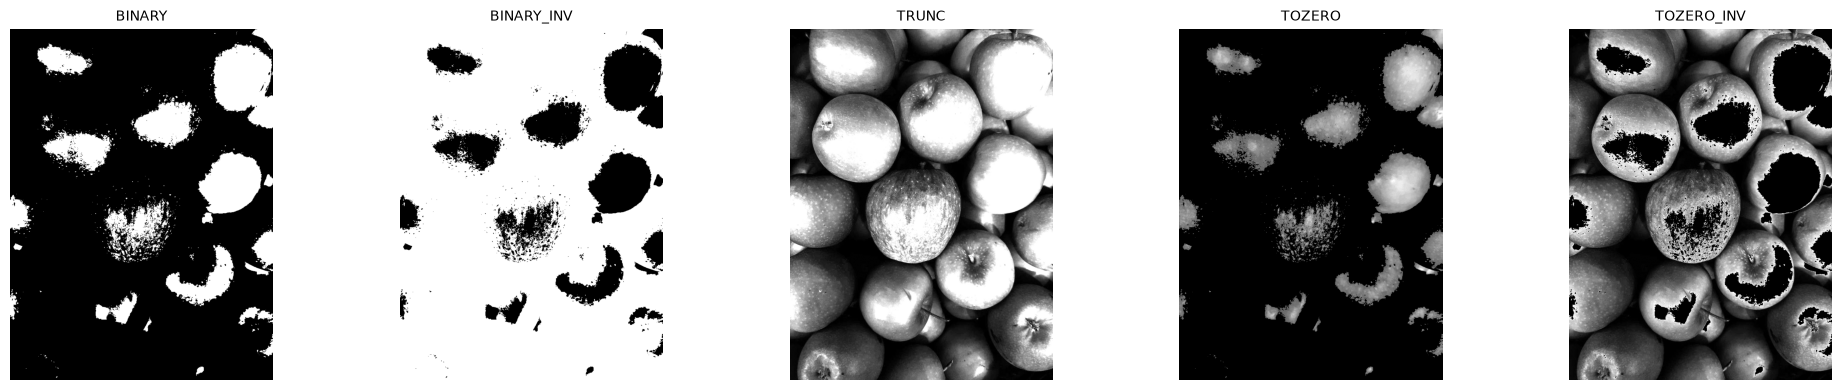

In [22]:
t = 100
modes = [(cv2.THRESH_BINARY,'BINARY'), (cv2.THRESH_BINARY_INV,'BINARY_INV'),
         (cv2.THRESH_TRUNC,'TRUNC'), (cv2.THRESH_TOZERO,'TOZERO'),
         (cv2.THRESH_TOZERO_INV,'TOZERO_INV')]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (mode, name) in zip(axes, modes):
    _, res = cv2.threshold(img, t, 255, mode)
    ax.imshow(res, cmap='gray')
    ax.set_title(name, fontsize=10)
    ax.axis('off')
plt.tight_layout(); plt.show()

Otsu порог: 76.0


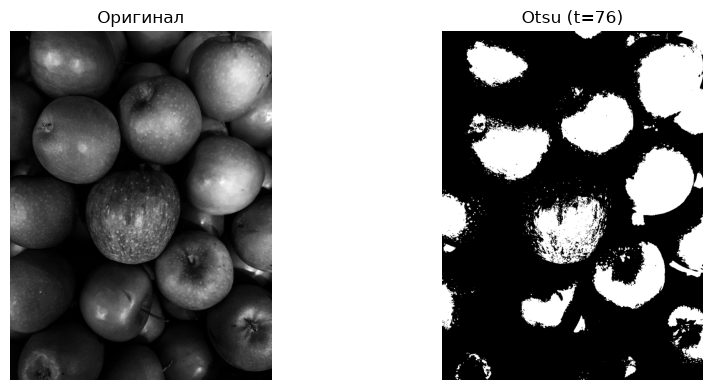

In [23]:
otsu_val, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Otsu порог:", otsu_val)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Оригинал'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(otsu, cmap='gray'); plt.title(f'Otsu (t={otsu_val:.0f})'); plt.axis('off')
plt.tight_layout(); plt.show()